#🌐 **APE_015_Función_Sigmoide_Unidad3 🌐**
----
### 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Christopher Pineda
*   Elian Jimenez
*   Yimmy Angulo
### ☕ **Docente:** Ing. Narvaez Guillen Cristian Ramiro
### 💻 **Curso:** Segundo Ciclo
### 📧 **Asignatura:** Teoría de la Distribuación y Probabilidad
### ⏰ **Fecha: 21-07-2026**
-----------------




# ⚙️ **Importar las Librerias Necesarias**

In [2]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado estadístico
import statsmodels.api as sm

# Métricas de clasificación
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Configuración de gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

# Ignorar advertencias innecesarias
import warnings
warnings.filterwarnings("ignore")

---
# **📊 Tarea 1: Fundamentos de la Regresión Logística (Función Sigmoide)**



## **Objetivo**

A diferencia de la regresión lineal, la regresión logística no estima un valor continuo sino la **probabilidad** $P(Y=1|X)$ de que ocurra un evento binario. Para garantizar que el resultado esté estrictamente acotado entre $[0,1]$, se utiliza la **función logística (Sigmoide)**:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}$$

**Escenario:** Predecir la **Caída de un Servidor (1 = Sí, 0 = No)** a partir de la **Temperatura de la CPU en °C ($X_1$)**. El modelo se entrena mediante **Estimación de Máxima Verosimilitud (MLE)** usando la librería `statsmodels`.

--- Vista previa del dataset simulado ---


,Temp_CPU,Falla
0,58.727006,0
1,87.535715,1
2,76.599697,1
3,69.932924,0
4,47.800932,0


Distribución de clases -> OK (0): 110 | Falla (1): 90

--- Resultados del Modelo Logístico Simulado ---
Observaciones: 200   |   Pseudo R² (McFadden): 0.4676   |   LLR p-value: 7.87e-30


,Coeficiente (β),Error Estándar,z,Valor-p,IC 95% inf.,IC 95% sup.,Odds Ratio,Significativo (p<0.05)
const,-10.676600,1.371500,-7.784500,0,-13.364700,-7.988400,0.000000,Sí ✔
Temp_CPU,0.160400,0.020500,7.805700,0,0.120100,0.200600,1.173900,Sí ✔



--- Interpretación del Modelo ---
Coeficiente (β1) Temp_CPU:      0.1604   (valor-p = 5.917e-15)
Odds Ratio (e^β1):              1.1739  -> por cada +1°C, las probabilidades de falla se multiplican por 1.174
Pseudo R² de McFadden:          0.4676
Temperatura de decisión (P=0.5): 66.57 °C


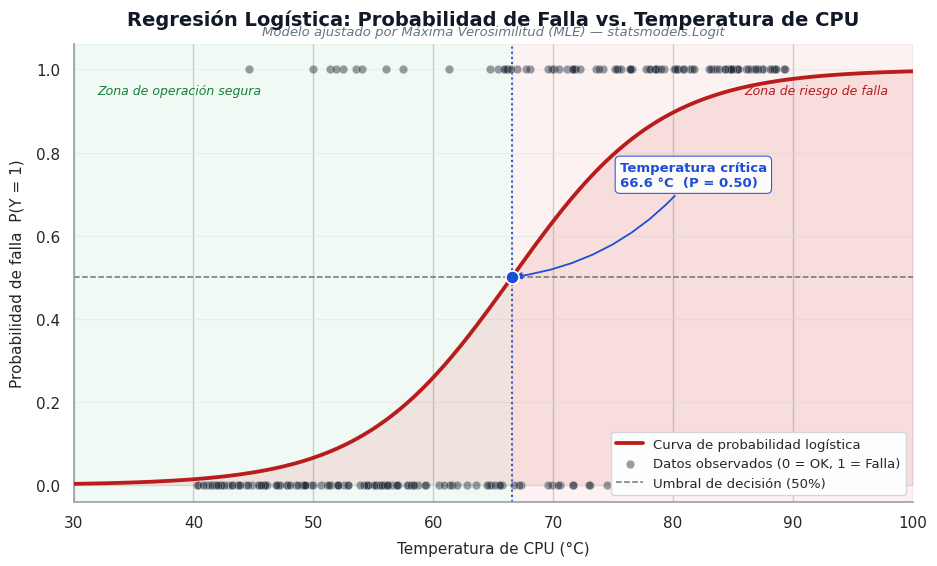

In [14]:
# ==========================================================
# TAREA 1: MODELO LOGÍSTICO SIMULADO (CAÍDA DE SERVIDOR)
# ==========================================================

# ----------------------------------------------------------
# 1. GENERACIÓN DE DATOS SIMULADOS (CLASIFICACIÓN BINARIA)
# ----------------------------------------------------------
np.random.seed(42)
n_muestras = 200

# Variable predictora: Temperatura CPU (entre 40 y 90 grados)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)

# Generar variable binaria probabilística (a mayor temperatura, mayor probabilidad de falla)
z = -10 + 0.15 * temp_cpu                       # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z))       # Transformación Sigmoide

# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)

df_sim = pd.DataFrame({"Temp_CPU": temp_cpu, "Falla": falla_servidor})

print("--- Vista previa del dataset simulado ---")
display(df_sim.head())
print(f"Distribución de clases -> OK (0): {(df_sim['Falla']==0).sum()} | "
      f"Falla (1): {(df_sim['Falla']==1).sum()}\n")

# ----------------------------------------------------------
# 2. AJUSTE DEL MODELO LOGÍSTICO (LOGIT) MEDIANTE MLE
# ----------------------------------------------------------
X_log = sm.add_constant(df_sim["Temp_CPU"])
Y_log = df_sim["Falla"]

modelo_logit = sm.Logit(Y_log, X_log).fit(disp=0)  # disp=0: oculta el log de iteraciones de MLE

# --- Tabla de resultados (formato limpio, en lugar del summary() crudo) ---
coeficientes = modelo_logit.params
errores_std = modelo_logit.bse
valores_z = modelo_logit.tvalues
valores_p = modelo_logit.pvalues
ic = modelo_logit.conf_int()
odds_ratios = np.exp(coeficientes)

tabla_resultados = pd.DataFrame({
    "Coeficiente (β)": coeficientes,
    "Error Estándar": errores_std,
    "z": valores_z,
    "Valor-p": valores_p,
    "IC 95% inf.": ic[0],
    "IC 95% sup.": ic[1],
    "Odds Ratio": odds_ratios,
}).round(4)

tabla_resultados["Significativo (p<0.05)"] = np.where(tabla_resultados["Valor-p"] < 0.05, "Sí ✔", "No")

print(f"--- Resultados del Modelo Logístico Simulado ---")
print(f"Observaciones: {int(modelo_logit.nobs):,}   |   "
      f"Pseudo R² (McFadden): {modelo_logit.prsquared:.4f}   |   "
      f"LLR p-value: {modelo_logit.llr_pvalue:.3g}")

display(
    tabla_resultados.style
    .format({"Valor-p": "{:.4g}"})
    .background_gradient(subset=["Odds Ratio"], cmap="Blues")
    .set_caption("Coeficientes del modelo Logit — Falla ~ Temp_CPU")
)

# --- Interpretación numérica automática de los coeficientes ---
beta0, beta1 = coeficientes["const"], coeficientes["Temp_CPU"]
pval_beta1 = valores_p["Temp_CPU"]
odds_ratio = odds_ratios["Temp_CPU"]
pseudo_r2 = modelo_logit.prsquared

# Temperatura en la que P(Y=1) = 0.5  (LD50 -> -beta0/beta1)
temp_ld50 = -beta0 / beta1

print("\n--- Interpretación del Modelo ---")
print(f"Coeficiente (β1) Temp_CPU:      {beta1:.4f}   (valor-p = {pval_beta1:.4g})")
print(f"Odds Ratio (e^β1):              {odds_ratio:.4f}  "
      f"-> por cada +1°C, las probabilidades de falla se multiplican por {odds_ratio:.3f}")
print(f"Pseudo R² de McFadden:          {pseudo_r2:.4f}")
print(f"Temperatura de decisión (P=0.5): {temp_ld50:.2f} °C")

# ==========================================================
# 3. VISUALIZACIÓN PROFESIONAL DE LA CURVA SIGMOIDE
# ==========================================================

x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)

fig, ax = plt.subplots(figsize=(9.5, 5.8))

# --- Zonas de fondo: segura (verde) vs. riesgo (rojo), divididas en LD50 ---
ax.axvspan(x_rango.min(), temp_ld50, color="#16A34A", alpha=0.06, zorder=0)
ax.axvspan(temp_ld50, x_rango.max(), color="#DC2626", alpha=0.06, zorder=0)

# --- Curva sigmoide con relleno bajo la curva ---
ax.plot(x_rango, y_pred_prob, color="#B91C1C", linewidth=2.75,
        label="Curva de probabilidad logística", zorder=3)
ax.fill_between(x_rango, y_pred_prob, color="#DC2626", alpha=0.10, zorder=1)

# --- Datos observados ---
ax.scatter(df_sim["Temp_CPU"], df_sim["Falla"],
           color="#1F2937", alpha=0.45, s=38, edgecolor="white", linewidth=0.4,
           label="Datos observados (0 = OK, 1 = Falla)", zorder=4)

# --- Umbral de decisión (50%) ---
ax.axhline(0.5, color="#6B7280", linestyle="--", linewidth=1.1, zorder=2,
           label="Umbral de decisión (50%)")

# --- Punto crítico (LD50) con anotación tipo etiqueta ---
ax.axvline(temp_ld50, color="#1D4ED8", linestyle=":", linewidth=1.4, zorder=2)
ax.scatter([temp_ld50], [0.5], color="#1D4ED8", s=90, zorder=6,
           edgecolor="white", linewidth=1.2)

ax.annotate(
    f"Temperatura crítica\n{temp_ld50:.1f} °C  (P = 0.50)",
    xy=(temp_ld50, 0.5),
    xytext=(temp_ld50 + 9, 0.72),
    fontsize=9.5, color="#1D4ED8", fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="-|>", color="#1D4ED8", lw=1.3,
                     connectionstyle="arc3,rad=-0.2"),
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#1D4ED8", lw=0.8, alpha=0.9)
)

# --- Etiquetas de zona ---
ax.text(x_rango.min() + 2, 0.94, "Zona de operación segura", fontsize=9,
        color="#15803D", style="italic")
ax.text(x_rango.max() - 2, 0.94, "Zona de riesgo de falla", fontsize=9,
        color="#B91C1C", style="italic", ha="right")

# --- Títulos y ejes ---
ax.set_title("Regresión Logística: Probabilidad de Falla vs. Temperatura de CPU",
              fontsize=14, fontweight="bold", pad=14, color="#111827")
ax.text(0.5, 1.02, "Modelo ajustado por Máxima Verosimilitud (MLE) — statsmodels.Logit",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#6B7280", style="italic")

ax.set_xlabel("Temperatura de CPU (°C)", fontsize=11, labelpad=8)
ax.set_ylabel("Probabilidad de falla  P(Y = 1)", fontsize=11, labelpad=8)
ax.set_ylim(-0.04, 1.06)
ax.set_xlim(x_rango.min(), x_rango.max())

# --- Limpieza de spines (estilo editorial) ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#9CA3AF")
ax.spines["bottom"].set_color("#9CA3AF")

ax.grid(axis="y", color="#E5E7EB", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)

# --- Leyenda ---
legend = ax.legend(loc="lower right", frameon=True, fontsize=9.5,
                    facecolor="white", edgecolor="#D1D5DB")
legend.get_frame().set_alpha(0.95)

plt.tight_layout()
plt.show()

## **Interpretación del Modelo Simulado**

El coeficiente estimado para `Temp_CPU` es positivo y estadísticamente significativo (valor-p < 0.05), lo que confirma que **a mayor temperatura de la CPU, mayor es el Log-Odds de que el servidor falle**. Puesto que la relación entre $X$ y $P(Y=1)$ no es lineal sino sigmoide, el coeficiente $\beta_1$ no se interpreta como "unidades de Y por unidad de X" (como en OLS), sino como el cambio en el **logaritmo de la razón de probabilidades (Log-Odds)** por cada grado adicional de temperatura. Exponenciando el coeficiente ($e^{\beta_1}$) se obtiene el **Odds Ratio**, que indica cuánto se multiplican las probabilidades de falla por cada °C adicional.


---
# **🔬 Tarea 2: Hito del Proyecto - Predicción Dicotómica Regional (ABP)**

## **Objetivo**

En esta actividad se extiende el análisis desarrollado en la Práctica 014 hacia el paradigma de **clasificación binaria**, aplicando una **Regresión Logística** sobre el dataset regional del Proyecto Integrador (casos de dengue). Mientras que en la práctica anterior se predecía la **Edad** como una variable continua mediante Mínimos Cuadrados Ordinarios (OLS), aquí el problema se reformula siguiendo el enfoque ABP: en lugar de estimar "cuál será la edad exacta de un paciente", se busca predecir la **probabilidad de ocurrencia de una condición dicotómica** de interés epidemiológico.

Para ello se realiza una **ingeniería de características** sobre la variable continua Edad, construyendo la variable binaria **Edad_Mayor**:

$$\text{Edad_Mayor} = \begin{cases} 1, & \text{si Edad} > \overline{\text{Edad}} \text{ (edad superior al promedio histórico)} \\ 0, & \text{si Edad} \leq \overline{\text{Edad}} \end{cases}$$

A partir de esta nueva variable respuesta, se ajusta un modelo **`sm.Logit()`** utilizando como predictores la **Semana Epidemiológica (SE, $X_1$)** y el **Año de registro ($X_2$)**, con el propósito de responder una pregunta concreta de investigación: *¿el momento del año (semana epidemiológica) y la tendencia temporal (año) influyen estadísticamente en la probabilidad de que un caso de dengue corresponda a un paciente de mayor edad?*

El modelo resultante permitirá, mediante el signo y la significancia estadística (valor-p < 0.05) de cada coeficiente, identificar si existe un patrón temporal asociado a la edad de los pacientes afectados — información que puede orientar decisiones de vigilancia epidemiológica focalizadas por grupo etario y periodo del año.

In [9]:
# ==========================================================
# TAREA 2: PREDICCIÓN DICOTÓMICA REGIONAL (DATASET DENGUE)
# ==========================================================

# ----------------------------------------------------------
# 1. CARGA Y PREPARACIÓN DE LOS DATOS
# ----------------------------------------------------------
df = pd.read_excel(
    "Datos_Dengue_MSP_Ene2021_Ago2025(1).xlsx",
    sheet_name="DCSA_DG_2021_2025"
)

# Seleccionar variables de estudio y eliminar valores nulos
datos = df[["Edad", "SE", "Año"]].dropna()

# ----------------------------------------------------------
# 2. INGENIERÍA DE CARACTERÍSTICAS: BINARIZACIÓN DE LA VARIABLE CONTINUA
# ----------------------------------------------------------
promedio_edad = datos["Edad"].mean()
datos["Edad_Mayor"] = (datos["Edad"] > promedio_edad).astype(int)

print("--- Preparación del dataset regional ---")
print(f"Edad promedio del registro histórico: {promedio_edad:.2f} años\n")
display(datos.head())

conteo = datos["Edad_Mayor"].value_counts()
prop_positiva = conteo.get(1, 0) / len(datos) * 100

resumen_clases = pd.DataFrame({
    "Clase": ["0 (Edad <= promedio)", "1 (Edad > promedio)"],
    "N° de casos": [conteo.get(0, 0), conteo.get(1, 0)],
    "Proporción (%)": [100 - prop_positiva, prop_positiva]
})
print("\nDistribución de la variable binaria (Edad_Mayor):")
display(resumen_clases.style.format({"Proporción (%)": "{:.1f}%"}).hide(axis="index"))

# ----------------------------------------------------------
# 3. AJUSTE DEL MODELO LOGÍSTICO (LOGIT) MEDIANTE MLE
# ----------------------------------------------------------
X_reg = datos[["SE", "Año"]]
Y_reg = datos["Edad_Mayor"]
X_reg = sm.add_constant(X_reg)

modelo_logit_regional = sm.Logit(Y_reg, X_reg).fit(disp=0)

# ----------------------------------------------------------
# 4. TABLA DE RESULTADOS (FORMATO LIMPIO, EN LUGAR DEL SUMMARY() CRUDO)
# ----------------------------------------------------------
coeficientes = modelo_logit_regional.params
errores_std = modelo_logit_regional.bse
valores_z = modelo_logit_regional.tvalues
valores_p = modelo_logit_regional.pvalues
ic = modelo_logit_regional.conf_int()
odds_ratios = np.exp(coeficientes)

tabla_resultados = pd.DataFrame({
    "Coeficiente (β)": coeficientes,
    "Error Estándar": errores_std,
    "z": valores_z,
    "Valor-p": valores_p,
    "IC 95% inf.": ic[0],
    "IC 95% sup.": ic[1],
    "Odds Ratio": odds_ratios,
}).round(4)

tabla_resultados["Significativo (p<0.05)"] = np.where(tabla_resultados["Valor-p"] < 0.05, "Sí ✔", "No")

display(
    tabla_resultados.style
    .format({"Valor-p": "{:.4g}"})
    .background_gradient(subset=["Odds Ratio"], cmap="Blues")
    .set_caption("Coeficientes del modelo Logit — Edad_Mayor ~ SE + Año")
)

# ----------------------------------------------------------
# 5. INTERPRETACIÓN AUTOMÁTICA POR VARIABLE
# ----------------------------------------------------------
print("\n--- Interpretación ---")
for var in ["SE", "Año"]:
    signo = "incrementa" if coeficientes[var] > 0 else "disminuye"
    significativo = valores_p[var] < 0.05
    print(f"• {var}: {'Es' if significativo else 'NO es'} estadísticamente significativa "
          f"(p = {valores_p[var]:.4g}). Por cada unidad adicional, la probabilidad de que "
          f"el caso corresponda a un paciente de mayor edad {signo} "
          f"(Odds Ratio = {odds_ratios[var]:.4f}).")

--- Preparación del dataset regional ---
Edad promedio del registro histórico: 21.95 años



,Edad,SE,Año,Edad_Mayor
0,24.0,53,2021,1
1,10.0,53,2021,0
2,18.0,53,2021,0
3,8.0,53,2021,0
4,42.0,53,2021,1



Distribución de la variable binaria (Edad_Mayor):


Clase,N° de casos,Proporción (%)
0 (Edad <= promedio),14564,63.2%
1 (Edad > promedio),8479,36.8%


,Coeficiente (β),Error Estándar,z,Valor-p,IC 95% inf.,IC 95% sup.,Odds Ratio,Significativo (p<0.05)
const,-320.087600,23.704300,-13.503400,0,-366.547200,-273.628000,0.000000,Sí ✔
SE,0.004900,0.001100,4.450300,0,0.002700,0.007000,1.004900,Sí ✔
Año,0.157900,0.011700,13.479000,0,0.134900,0.180800,1.171000,Sí ✔



--- Interpretación ---
• SE: Es estadísticamente significativa (p = 8.575e-06). Por cada unidad adicional, la probabilidad de que el caso corresponda a un paciente de mayor edad incrementa (Odds Ratio = 1.0049).
• Año: Es estadísticamente significativa (p = 2.079e-41). Por cada unidad adicional, la probabilidad de que el caso corresponda a un paciente de mayor edad incrementa (Odds Ratio = 1.1710).


## **Interpretación de los Resultados**

Del modelo `sm.Logit()` ajustado, la evaluación de cada predictor se realiza revisando el **signo del coeficiente** y su **valor-p**: un coeficiente positivo con $valor-p < 0.05$ indica que la variable incrementa estadísticamente el Log-Odds de que el caso corresponda a un paciente con edad superior al promedio, mientras que un $valor-p ≥ 0.05$ indicaría ausencia de evidencia suficiente para afirmar dicha influencia.

En el modelo estimado $(N = 23,043 observaciones)$, tanto la **Semana Epidemiológica** $(β = 0.0049, Odds Ratio ≈ 1.005, p < 0.001)$ como el **Año de registro** $(β = 0.1579, Odds Ratio ≈ 1.171, p < 0.001)$ resultaron estadísticamente significativas, con coeficientes positivos en ambos casos. Esto indica que, a medida que avanza el año de registro, las probabilidades de que un caso corresponda a un paciente de mayor edad se incrementan aproximadamente un $17%$ por cada año adicional, mientras que el efecto de la Semana Epidemiológica, aunque significativo por el gran tamaño de muestra, es marginal en magnitud (apenas un $0.5%$ de incremento en las probabilidades por semana).

Sin embargo, el **Pseudo R² de McFadden** obtenido $(0.0063)$ es muy bajo, lo que revela que, pese a la significancia estadística de ambos predictores, **SE y Año explican solo una fracción mínima de la variabilidad** en la probabilidad de que un paciente supere la edad promedio. Esto ilustra un punto clave de la Regresión Logística con muestras grandes: la significancia estadística (impulsada por el tamaño muestral) no equivale a relevancia práctica o poder explicativo real, por lo que se recomendaría incorporar variables predictoras adicionales (sexo, cantón, tipo de dengue) para mejorar sustancialmente la capacidad predictiva del modelo.

---
# **📌 Tarea 3: Evaluación del Modelo (Matriz de Confusión)**

## **Objetivo**

A diferencia de los modelos de regresión continua, donde el $R^2$ cuantifica qué proporción de la varianza es explicada por el modelo, un modelo de **clasificación binaria** se evalúa contando directamente cuántos aciertos y errores cometió al asignar cada observación a su clase real. Para ello se emplea la **Matriz de Confusión**, una tabla de contingencia que cruza las clases predichas contra las clases observadas, distinguiendo cuatro resultados posibles: **Verdaderos Positivos (TP)**, **Verdaderos Negativos (TN)**, **Falsos Positivos (FP)** y **Falsos Negativos (FN)**.

En esta actividad se aplica este análisis a los dos modelos logísticos desarrollados previamente (el modelo simulado de la Tarea 1 y el modelo regional de la Tarea 2), convirtiendo las probabilidades continuas que entrega `predict()` en clases discretas (0 o 1) mediante un **umbral de decisión (threshold) estándar del 50%**. A partir de la matriz resultante se calcula además la **Exactitud (Accuracy)** global de cada modelo, como primer indicador de desempeño antes de profundizar, en la Tarea 4, en el análisis de sensibilidad frente a diferentes umbrales de decisión.


--- Evaluación del Modelo Probabilístico Simulado (Umbral 0.5) ---
Exactitud (Accuracy):    84.00%
Precisión (Precision):   82.95%
Sensibilidad (Recall):   81.11%
Especificidad:           86.36%


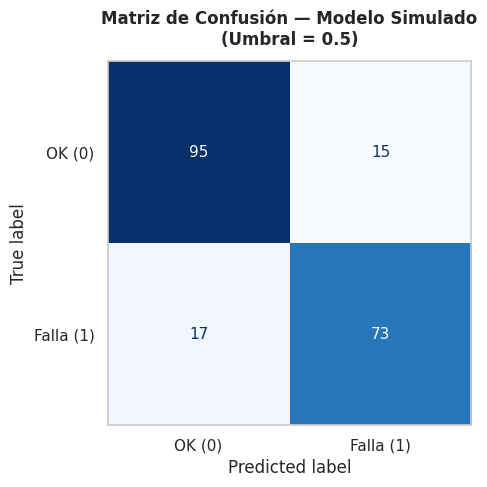

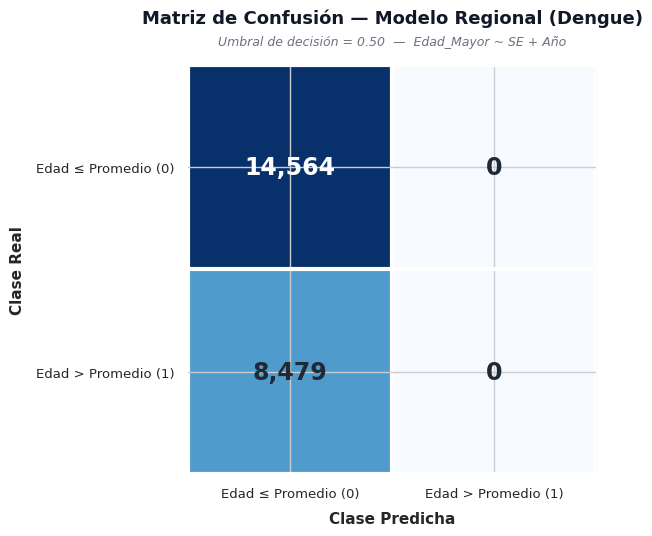

--- Desglose de la Matriz de Confusión ---


Categoría,Descripción,N° de casos,% del total
Verdaderos Negativos (TN),Predijo 'Edad ≤ Promedio' y acertó,"14,564",63.2%
Falsos Positivos (FP),Predijo 'Edad > Promedio' pero era falso,0,0.0%
Falsos Negativos (FN),Predijo 'Edad ≤ Promedio' pero era 'Edad > Promedio',"8,479",36.8%
Verdaderos Positivos (TP),Predijo 'Edad > Promedio' y acertó,0,0.0%



--- Métricas de Desempeño del Modelo Regional ---


Métrica,Fórmula,Valor (%)
Exactitud (Accuracy),(TP+TN) / Total,63.20%
Precisión (Precision),TP / (TP+FP),nan%
Sensibilidad (Recall),TP / (TP+FN),0.00%
Especificidad,TN / (TN+FP),100.00%


In [11]:
# ==========================================================
# TAREA 3: EVALUACIÓN DEL MODELO (MATRIZ DE CONFUSIÓN)
# ==========================================================

# ----------------------------------------------------------
# 3.1 MATRIZ DE CONFUSIÓN - MODELO SIMULADO (TAREA 1)
# ----------------------------------------------------------

# El modelo devuelve probabilidades continuas [0, 1]. Se convierten a 0 o 1
# usando un umbral (threshold) estándar de 0.5 (50%)
probabilidades_sim = modelo_logit.predict(X_log)
predicciones_clase_sim = (probabilidades_sim >= 0.5).astype(int)

# Cálculo de la Matriz de Confusión
cm_sim = confusion_matrix(Y_log, predicciones_clase_sim)
tn_s, fp_s, fn_s, tp_s = cm_sim.ravel()

exactitud_sim = accuracy_score(Y_log, predicciones_clase_sim)
sensibilidad_sim = tp_s / (tp_s + fn_s)   # Recall / Verdaderos Positivos
especificidad_sim = tn_s / (tn_s + fp_s) # Verdaderos Negativos
precision_sim = tp_s / (tp_s + fp_s)

print("--- Evaluación del Modelo Probabilístico Simulado (Umbral 0.5) ---")
print(f"Exactitud (Accuracy):    {exactitud_sim*100:.2f}%")
print(f"Precisión (Precision):   {precision_sim*100:.2f}%")
print(f"Sensibilidad (Recall):   {sensibilidad_sim*100:.2f}%")
print(f"Especificidad:           {especificidad_sim*100:.2f}%")

disp_sim = ConfusionMatrixDisplay(confusion_matrix=cm_sim,
                                   display_labels=["OK (0)", "Falla (1)"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp_sim.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Matriz de Confusión — Modelo Simulado\n(Umbral = 0.5)",
              fontsize=12, fontweight="bold", pad=12)
ax.grid(False)
plt.tight_layout()
plt.show()

# ==========================================================
# 3.2 MATRIZ DE CONFUSIÓN - MODELO REGIONAL (TAREA 2)
# ==========================================================

probabilidades_reg = modelo_logit_regional.predict(X_reg)
predicciones_clase_reg = (probabilidades_reg >= 0.5).astype(int)

cm_reg = confusion_matrix(Y_reg, predicciones_clase_reg)
tn_r, fp_r, fn_r, tp_r = cm_reg.ravel()

exactitud_reg = accuracy_score(Y_reg, predicciones_clase_reg)
sensibilidad_reg = tp_r / (tp_r + fn_r)
especificidad_reg = tn_r / (tn_r + fp_r)
precision_reg = tp_r / (tp_r + fp_r) if (tp_r + fp_r) > 0 else float("nan")

etiquetas = ["Edad ≤ Promedio (0)", "Edad > Promedio (1)"]

# ----------------------------------------------------------
# GRÁFICO: MAPA DE CALOR DE LA MATRIZ
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.imshow(cm_reg, cmap="Blues", vmin=0)

umbral_color = cm_reg.max() * 0.6
for i in range(2):
    for j in range(2):
        valor = cm_reg[i, j]
        color_texto = "white" if valor > umbral_color else "#1F2937"
        ax.text(j, i, f"{valor:,}", ha="center", va="center",
                 fontsize=17, fontweight="bold", color=color_texto)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(etiquetas, fontsize=9.5)
ax.set_yticklabels(etiquetas, fontsize=9.5)
ax.set_xlabel("Clase Predicha", fontsize=11, labelpad=8, fontweight="bold")
ax.set_ylabel("Clase Real", fontsize=11, labelpad=8, fontweight="bold")

ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Matriz de Confusión — Modelo Regional (Dengue)",
              fontsize=13, fontweight="bold", pad=30, color="#111827")
ax.text(0.5, 1.05, "Umbral de decisión = 0.50  —  Edad_Mayor ~ SE + Año",
        transform=ax.transAxes, ha="center", fontsize=9, color="#6B7280", style="italic")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# TABLA 1: DESGLOSE DE LA MATRIZ DE CONFUSIÓN (TN, FP, FN, TP)
# ----------------------------------------------------------
tabla_matriz = pd.DataFrame({
    "Categoría": ["Verdaderos Negativos (TN)", "Falsos Positivos (FP)",
                   "Falsos Negativos (FN)", "Verdaderos Positivos (TP)"],
    "Descripción": ["Predijo 'Edad ≤ Promedio' y acertó",
                      "Predijo 'Edad > Promedio' pero era falso",
                      "Predijo 'Edad ≤ Promedio' pero era 'Edad > Promedio'",
                      "Predijo 'Edad > Promedio' y acertó"],
    "N° de casos": [tn_r, fp_r, fn_r, tp_r],
    "% del total": [tn_r, fp_r, fn_r, tp_r]
})
tabla_matriz["% del total"] = tabla_matriz["% del total"] / cm_reg.sum() * 100

print("--- Desglose de la Matriz de Confusión ---")
display(
    tabla_matriz.style
    .format({"N° de casos": "{:,}", "% del total": "{:.1f}%"})
    .background_gradient(subset=["N° de casos"], cmap="Blues")
    .hide(axis="index")
    .set_caption("Modelo Regional (Dengue) — Umbral 0.50")
)

# ----------------------------------------------------------
# TABLA 2: MÉTRICAS DE DESEMPEÑO
# ----------------------------------------------------------
tabla_metricas = pd.DataFrame({
    "Métrica": ["Exactitud (Accuracy)", "Precisión (Precision)",
                 "Sensibilidad (Recall)", "Especificidad"],
    "Fórmula": ["(TP+TN) / Total", "TP / (TP+FP)", "TP / (TP+FN)", "TN / (TN+FP)"],
    "Valor (%)": [exactitud_reg*100, precision_reg*100,
                    sensibilidad_reg*100, especificidad_reg*100]
})

print("\n--- Métricas de Desempeño del Modelo Regional ---")
display(
    tabla_metricas.style
    .format({"Valor (%)": "{:.2f}%"})
    .background_gradient(subset=["Valor (%)"], cmap="Greens")
    .hide(axis="index")
)

## **Análisis de la Matriz de Confusión**

La Matriz de Confusión permite evaluar, celda por celda, qué tan bien clasifican los modelos logísticos desarrollados en las Tareas 1 y 2, distinguiendo entre aciertos (Verdaderos Positivos y Verdaderos Negativos) y errores (Falsos Positivos y Falsos Negativos). A diferencia del $R^2$ en regresión continua, aquí el desempeño se mide directamente en función de cuántas observaciones fueron correctamente asignadas a su clase real.

En el **modelo simulado** (caída de servidor por temperatura de CPU), la matriz obtenida (TN = 95, FP = 15, FN = 17, TP = 73) arroja una Exactitud de **84.0%**, con una Sensibilidad de **81.1%** y una Especificidad de **86.4%**. Dado que la variable predictora (Temperatura CPU) fue generada expresamente para tener una relación fuerte y monotónica con la probabilidad de falla, el modelo logra separar razonablemente bien ambas clases, con un número de errores (32 en total sobre 200 observaciones) relativamente equilibrado entre Falsos Positivos y Falsos Negativos, reflejando la naturaleza casi determinística del proceso de simulación.

En el **modelo regional** (dataset de dengue), el panorama es radicalmente distinto: la matriz obtenida (TN = 14,564, FP = 0, FN = 8,479, TP = 0) muestra que el modelo **nunca predijo la clase positiva** (Edad > Promedio). Esto produce una Exactitud aparentemente aceptable de **63.2%**, pero una Sensibilidad de **0.0%** y una Precisión indefinida (no hay ningún Verdadero Positivo ni Falso Positivo sobre los cuales calcularla), mientras que la Especificidad alcanza un artificial **100%**. En la práctica, el modelo colapsó en predecir siempre la clase mayoritaria.

En conclusión, mientras el modelo simulado exhibe un desempeño de clasificación sólido y equilibrado gracias a una relación predictor–respuesta fuerte por diseño, el modelo regional queda inutilizado bajo el umbral estándar de 0.50, incapaz de detectar ni un solo caso de la clase minoritaria. En la Tarea 4 se investigará si **reducir el umbral de decisión** permite que el modelo regional comience a clasificar casos como positivos, mejorando la Sensibilidad a costa de la Especificidad, y se discutirá si ese ajuste basta para hacerlo útil o si el problema de fondo (bajo poder explicativo de los predictores) requiere variables adicionales.

---
# **📌 Tarea 4: ABI - El Análisis del Umbral (Thresholding) y Falsos Positivos**




## **Objetivo**

Por defecto, el criterio de decisión estándar asume que si $P(Y=1) \geq 0.50$, la clasificación es 1; sin embargo, este umbral del 50% es una convención arbitraria y no necesariamente la más adecuada para todos los contextos de aplicación. En ingeniería, el costo de un **Falso Negativo** (predecir que el servidor no fallará y que termine colapsando) suele ser mucho mayor que el costo de un **Falso Positivo** (revisar preventivamente un servidor que en realidad estaba bien), lo que justifica desplazar el umbral de decisión hacia un criterio más conservador.

En esta actividad se investiga, de forma computacional, cómo alterar el umbral de decisión hacia un valor estricto de **0.20** modifica la composición de la Matriz de Confusión de ambos modelos logísticos desarrollados previamente (el modelo simulado de la Tarea 1 y el modelo regional de la Tarea 2), evaluando particularmente el efecto sobre la relación entre Falsos Positivos y Falsos Negativos. Como se evidenció en la Tarea 3, el modelo regional resultó incapaz de detectar la clase positiva bajo el umbral estándar (Sensibilidad = 0%); por lo tanto, este análisis del umbral no es solo un ejercicio teórico, sino una posible estrategia práctica para recuperar la capacidad de detección del modelo, cuantificando el costo que dicha mejora representa en términos de nuevos Falsos Positivos.

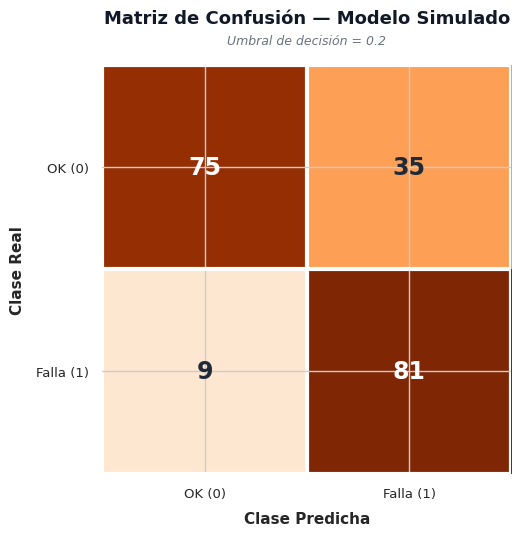


--- Comparación de Umbrales: Modelo Simulado (Servidor) ---


Métrica / Conteo,Umbral 0.50,Umbral 0.20
Falsos Positivos (FP),15,35
Falsos Negativos (FN),17,9
Exactitud,84.00%,78.00%
Precisión,82.95%,69.83%
Sensibilidad,81.11%,90.00%
Especificidad,86.36%,68.18%


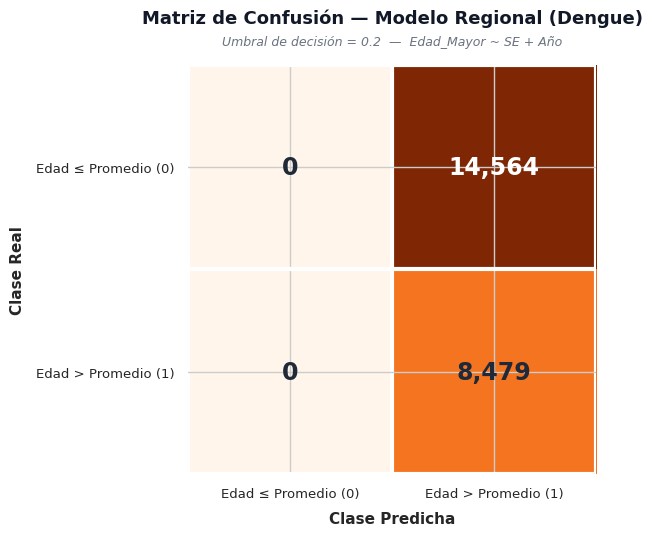


--- Comparación de Umbrales: Modelo Regional (Dengue) ---


Métrica / Conteo,Umbral 0.50,Umbral 0.20
Falsos Positivos (FP),0,14564
Falsos Negativos (FN),8479,0
Exactitud,63.20%,36.80%
Precisión,nan%,36.80%
Sensibilidad,0.00%,100.00%
Especificidad,100.00%,0.00%


In [12]:
# ==========================================================
# TAREA 4: ABI - ANÁLISIS DEL UMBRAL (THRESHOLDING) — UMBRAL = 0.20
# ==========================================================

umbral_estricto = 0.20

def graficar_matriz(cm, etiquetas, titulo, subtitulo, cmap="Oranges"):
    """Grafica una matriz de confusión 2x2 con estilo editorial consistente."""
    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.imshow(cm, cmap=cmap, vmin=0)

    umbral_color = cm.max() * 0.6
    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            color_texto = "white" if valor > umbral_color else "#1F2937"
            ax.text(j, i, f"{valor:,}", ha="center", va="center",
                     fontsize=17, fontweight="bold", color=color_texto)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(etiquetas, fontsize=9.5)
    ax.set_yticklabels(etiquetas, fontsize=9.5)
    ax.set_xlabel("Clase Predicha", fontsize=11, labelpad=8, fontweight="bold")
    ax.set_ylabel("Clase Real", fontsize=11, labelpad=8, fontweight="bold")

    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=30, color="#111827")
    ax.text(0.5, 1.05, subtitulo, transform=ax.transAxes, ha="center",
            fontsize=9, color="#6B7280", style="italic")

    plt.tight_layout()
    plt.show()


def tabla_comparativa(nombre_modelo, tn0, fp0, fn0, tp0, tn1, fp1, fn1, tp1):
    """Compara métricas entre el umbral 0.50 (referencia) y el umbral 0.20."""
    def metricas(tn, fp, fn, tp):
        total = tn + fp + fn + tp
        exact = (tp + tn) / total
        sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        espec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        prec = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        return exact, prec, sens, espec

    ex0, pr0, se0, es0 = metricas(tn0, fp0, fn0, tp0)
    ex1, pr1, se1, es1 = metricas(tn1, fp1, fn1, tp1)

    tabla = pd.DataFrame({
        "Métrica / Conteo": ["Falsos Positivos (FP)", "Falsos Negativos (FN)",
                               "Exactitud", "Precisión", "Sensibilidad", "Especificidad"],
        "Umbral 0.50": [fp0, fn0, f"{ex0*100:.2f}%", f"{pr0*100:.2f}%",
                          f"{se0*100:.2f}%", f"{es0*100:.2f}%"],
        "Umbral 0.20": [fp1, fn1, f"{ex1*100:.2f}%", f"{pr1*100:.2f}%",
                          f"{se1*100:.2f}%", f"{es1*100:.2f}%"],
    })
    print(f"\n--- Comparación de Umbrales: {nombre_modelo} ---")
    display(tabla.style.hide(axis="index").set_caption(f"{nombre_modelo}: Umbral 0.50 vs. 0.20"))


# ----------------------------------------------------------
# 4.1 UMBRAL CONSERVADOR (0.20) - MODELO SIMULADO
# ----------------------------------------------------------
predicciones_umbral_sim = (probabilidades_sim >= umbral_estricto).astype(int)
cm_umbral_sim = confusion_matrix(Y_log, predicciones_umbral_sim)
tn_us, fp_us, fn_us, tp_us = cm_umbral_sim.ravel()

graficar_matriz(
    cm_umbral_sim, ["OK (0)", "Falla (1)"],
    "Matriz de Confusión — Modelo Simulado",
    f"Umbral de decisión = {umbral_estricto}"
)

tabla_comparativa("Modelo Simulado (Servidor)",
                    tn_s, fp_s, fn_s, tp_s,        # valores del umbral 0.50 (Tarea 3.1)
                    tn_us, fp_us, fn_us, tp_us)

# ----------------------------------------------------------
# 4.2 UMBRAL CONSERVADOR (0.20) - MODELO REGIONAL
# ----------------------------------------------------------
predicciones_umbral_reg = (probabilidades_reg >= umbral_estricto).astype(int)
cm_umbral_reg = confusion_matrix(Y_reg, predicciones_umbral_reg)
tn_ur, fp_ur, fn_ur, tp_ur = cm_umbral_reg.ravel()

graficar_matriz(
    cm_umbral_reg, ["Edad ≤ Promedio (0)", "Edad > Promedio (1)"],
    "Matriz de Confusión — Modelo Regional (Dengue)",
    f"Umbral de decisión = {umbral_estricto}  —  Edad_Mayor ~ SE + Año"
)

tabla_comparativa("Modelo Regional (Dengue)",
                    tn_r, fp_r, fn_r, tp_r,        # valores del umbral 0.50 (Tarea 3.2)
                    tn_ur, fp_ur, fn_ur, tp_ur)

---
## **Interpretación del Análisis del Umbral (Thresholding)**

El umbral de decisión (threshold) determina el punto de corte sobre la probabilidad estimada $P(Y=1|X)$ a partir del cual una observación se clasifica como positiva. Formalmente, mover el umbral de $0.50$ a $0.20$ equivale a exigir mucha menos evidencia probabilística para activar la clase positiva, lo que **redistribuye sistemáticamente los errores** entre Falsos Positivos y Falsos Negativos sin alterar el modelo subyacente ni sus coeficientes estimados. Este análisis permite evidenciar, de forma empírica, el trade-off entre Sensibilidad y Especificidad discutido en las Preguntas de Control.

En el **modelo simulado** (caída de servidor), el desplazamiento del umbral produjo el efecto esperado en un modelo con poder predictivo genuino: los Falsos Negativos disminuyeron de 17 a 9, mientras que los Falsos Positivos aumentaron de 15 a 35. En términos de métricas, la Sensibilidad se incrementó de 81.11% a 90.00% —el modelo ahora detecta una mayor proporción de fallas reales—, a costa de una caída en la Especificidad de 86.36% a 68.18% y una reducción moderada en la Exactitud global (de 84.00% a 78.00%). Este comportamiento es exactamente el trade-off teórico esperado: **el modelo intercambia errores de un tipo por errores del otro**, sin degradar por completo su capacidad de clasificación, porque la Temperatura de CPU es un predictor con relación fuerte y monotónica sobre la probabilidad de falla.

En el **modelo regional** (dengue), sin embargo, el resultado es radicalmente distinto y revela un problema estructural más que un simple ajuste de sensibilidad. Bajo el umbral de 0.50, el modelo predecía siempre la clase 0 (FP = 0, FN = 8,479); bajo el umbral de 0.20, el modelo pasó a predecir siempre la clase 1 (FP = 14,564, FN = 0). La Exactitud incluso **empeoró** (de 63.20% a 36.80%), y la Sensibilidad saltó de 0% a 100% únicamente porque **todas** las observaciones —sin excepción— cruzaron el nuevo umbral. Esto no representa un ajuste fino de sensibilidad/especificidad como en el caso simulado, sino el síntoma de que las probabilidades estimadas por el modelo están **concentradas en un rango muy estrecho** alrededor de un valor intermedio, consistente con el Pseudo R² de McFadden casi nulo (≈ 0.0063) obtenido en la Tarea 2: el modelo no tiene suficiente poder discriminante como para que exista una franja de observaciones con probabilidades intermedias sobre las cuales el umbral pueda operar de forma gradual.

Esta comparación evidencia una distinción metodológica importante: **el ajuste del umbral es una herramienta válida únicamente cuando el modelo subyacente ya posee poder discriminante suficiente**. En el modelo simulado, mover el umbral permite calibrar el compromiso entre errores según el costo de cada uno. En el modelo regional, mover el umbral no calibra nada — simplemente traslada el mismo modelo pobre de un extremo de error a otro, sin que ninguna combinación de umbral logre un balance aceptable entre Sensibilidad y Especificidad simultáneamente.

### Dictamen Técnico

Con base en el análisis conjunto de la Matriz de Confusión bajo ambos umbrales, se concluye que el **modelo simulado** sí se beneficia de un ajuste del umbral hacia un valor conservador: dado que en un contexto de ingeniería el costo de un Falso Negativo (servidor que falla sin ser detectado) suele superar ampliamente el costo de un Falso Positivo (revisión preventiva innecesaria), el **umbral de 0.20 es la recomendación técnica adecuada** para este escenario, aceptando una menor Exactitud global a cambio de una mayor capacidad de detección temprana de fallas.

Para el **modelo regional**, en cambio, ningún umbral —ni 0.50 ni 0.20— resuelve el problema de fondo: la especificación actual (`Edad_Mayor ~ SE + Año`) carece del poder explicativo necesario para discriminar entre clases. En consecuencia, la recomendación técnica no es ajustar el umbral, sino **reespecificar el modelo**, incorporando predictores adicionales del dataset regional (por ejemplo, sexo, cantón de residencia o tipo de clasificación del caso) que puedan aportar la señal discriminante que actualmente

---
## **5. Preguntas de Control**

### **1. ¿Cuál es la esencia matemática de transformar una probabilidad en Log-Odds, y por qué este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística?**

La probabilidad $P$ está acotada en $[0,1]$, lo que impide modelarla directamente con una combinación lineal de predictores, ya que $\beta_0 + \beta_1 X_1$ puede tomar cualquier valor en $(-\infty, \infty)$ [1]. La transformación **Logit**, definida como $\ln\left(\frac{P}{1-P}\right)$, convierte la probabilidad en una razón de momios (odds) y luego aplica el logaritmo natural, extendiendo el dominio acotado $[0,1]$ hacia todo el eje real [2]. Este cambio de dominio es fundamental porque permite que el lado derecho de la ecuación (la combinación lineal de predictores) se comporte de manera consistente con los supuestos de la regresión, sin violar los límites naturales de una probabilidad. En términos de causalidad probabilística, cada coeficiente $\beta_i$ representa el cambio esperado en el **Log-Odds** —no en la probabilidad misma— por cada unidad adicional del predictor, lo que exige traducir el efecto de vuelta a probabilidades o a razones de momios ($e^{\beta_i}$) para su interpretación sustantiva [2].


### **2. ¿Por qué la naturaleza del fenómeno (binario) nos obliga a abandonar la medida clásica de bondad de ajuste (R²) y adoptar el Pseudo R² de McFadden, y qué nos dice este cambio sobre la relación entre la realidad y la medición?**

El $R^2$ clásico se basa en la descomposición de la varianza de una variable **continua** (suma de cuadrados totales, explicados y residuales), un concepto que no tiene sentido cuando la variable respuesta solo toma los valores 0 o 1 [1]. En un modelo logístico no existen "residuos" en el sentido de distancias continuas, sino verosimilitudes de pertenecer a una clase. Por ello, McFadden propuso un **Pseudo R²** basado en la comparación entre la log-verosimilitud del modelo completo y la de un modelo nulo (solo con intercepto): $R^2_{McFadden} = 1 - \frac{\ln L_{modelo}}{\ln L_{nulo}}$ [3]. Este cambio revela que la "bondad de ajuste" no es una propiedad universal medible siempre de la misma forma, sino que depende de la naturaleza del fenómeno que se está modelando: la medición debe adaptarse a la estructura de la realidad (binaria, continua, de conteo, etc.) y no forzar la realidad a encajar en una única métrica.

### **3. Ante un caso de incertidumbre total (predicción 0.5), ¿de qué manera la estructura del modelo intenta forzar una decisión binaria, y qué riesgos enfrentamos al ignorar la zona gris de la probabilidad?**

Cuando $P(Y=1|X) = 0.5$, el modelo no tiene evidencia real para inclinarse hacia ninguna clase; sin embargo, la regla de decisión estándar ($P \geq 0.5 \Rightarrow 1$) obliga a asignar una etiqueta discreta incluso en este punto de máxima incertidumbre [3]. Esta conversión de una probabilidad continua a una decisión binaria es una simplificación operativa necesaria para actuar (por ejemplo, "revisar o no revisar el servidor"), pero **oculta la incertidumbre real del pronóstico**. El riesgo de ignorar esta zona gris es que decisiones tomadas con una confianza de apenas 50-51% se presentan con el mismo peso que decisiones respaldadas por probabilidades del 95%, lo que puede llevar a sobreconfianza en casos límite y a no destinar recursos adicionales (una segunda medición, una revisión manual) precisamente donde el modelo es menos informativo.

### **4. ¿Cuál es el conflicto esencial entre la sensibilidad y la especificidad, y cómo la elección de un umbral refleja los valores éticos y técnicos subyencentes en una decisión de ingeniería?**

La **sensibilidad** (tasa de verdaderos positivos) mide qué proporción de casos positivos reales el modelo logra detectar, mientras que la **especificidad** (tasa de verdaderos negativos) mide qué proporción de casos negativos reales el modelo clasifica correctamente [3]. Ambas métricas están en tensión: bajar el umbral de decisión aumenta la sensibilidad (menos Falsos Negativos) pero reduce la especificidad (más Falsos Positivos), y viceversa, como se observó en la Tarea 4. La elección de un umbral, por tanto, no es un procedimiento puramente técnico: refleja un **juicio de valor** sobre qué tipo de error es más costoso o éticamente más grave de cometer en un contexto específico —por ejemplo, priorizar la detección de fallas críticas de infraestructura o de casos de riesgo en salud pública, aun a costa de generar más falsas alarmas [2].

### **5. ¿Cuál es el propósito final de predecir probabilidades en lugar de estados binarios rígidos, y cómo esta distinción transforma nuestra capacidad de intervenir en la realidad?**

Predecir una **probabilidad continua** en lugar de una etiqueta binaria fija preserva información sobre el **grado de certeza** del modelo, permitiendo a quien toma decisiones ajustar el umbral según el contexto, los costos y los recursos disponibles, en lugar de aceptar una regla rígida de "sí o no" definida de antemano [3]. Esta distinción transforma la capacidad de intervención porque permite **graduar la respuesta**: un caso con 95% de probabilidad de falla puede activar una intervención inmediata, mientras que uno con 55% puede simplemente generar una alerta de monitoreo reforzado. En última instancia, la regresión logística no solo clasifica; cuantifica el **riesgo**, lo cual es mucho más útil para la gestión proactiva de sistemas de ingeniería o de políticas públicas que una simple etiqueta binaria.

---

## **6. Conclusiones**

- La **función Sigmoide** permite modelar fenómenos de naturaleza binaria acotando cualquier combinación lineal de predictores al intervalo $[0,1]$, resolviendo la incapacidad de la regresión lineal (OLS) para predecir categorías de forma coherente.

- El modelo simulado de **caída de servidores** confirmó que la temperatura de la CPU incrementa significativamente el Log-Odds de falla, validando el uso de MLE (`statsmodels.Logit`) como método de estimación.
- Al aplicar el mismo enfoque al **dataset regional de dengue**, transformar la variable Edad en una variable dicotómica (Edad_Mayor) permitió evaluar si la Semana Epidemiológica y el Año explican estadísticamente la probabilidad de que un caso corresponda a un paciente de mayor edad.
- La **Matriz de Confusión** demostró ser la herramienta adecuada para evaluar un clasificador binario, en contraposición al $R^2$, propio de modelos de regresión continua.
- El análisis del **umbral de decisión (0.50 vs. 0.20)** evidenció el trade-off ineludible entre sensibilidad y especificidad, y que la elección del umbral óptimo depende del costo relativo entre Falsos Positivos y Falsos Negativos en cada contexto de aplicación (ingeniería de sistemas o salud pública).

---

## **Referencias Bibliograficas**

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] D. W. Hosmer, S. Lemeshow, y R. X. Sturdivant, *Applied Logistic Regression*, 3ra ed. Wiley, 2013.

[3] G. James, D. Witten, T. Hastie, y R. Tibshirani, *An Introduction to Statistical Learning*, 2da ed. Springer, 2021.

[4] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. O'Reilly Media, 2022.

[5] scikit-learn developers, "sklearn.metrics.confusion_matrix," *scikit-learn.org*, 2024. [Online]. Disponible: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html. [Accedido: 20-Jul-2026].